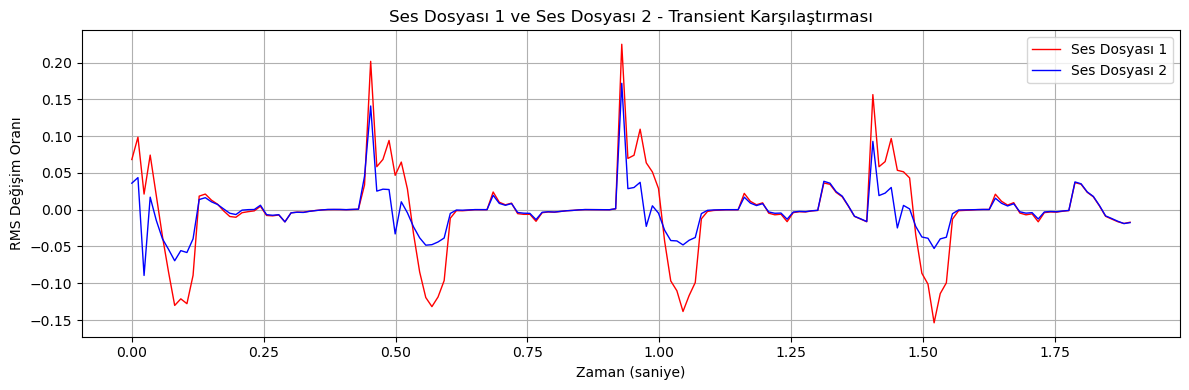

In [8]:
# Kütüphaneler ve işleme araçları
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav"
file_2 = "/Users/nazimerensahin/Desktop/2.wav"

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1"
label_2 = "Ses Dosyası 2"

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None)
wave_2, sr_2 = librosa.load(file_2, sr=None)

# Transient (ani enerji değişimi) hesaplama fonksiyonu
def compute_transient(signal, sr, hop_length):
    rms = librosa.feature.rms(y=signal, 
hop_length=hop_length)[0]
    delta_rms = np.diff(rms)
    times = librosa.times_like(delta_rms, sr=sr, 
hop_length=hop_length)
    return delta_rms, times

# Transient analizinde çözünürlüğü belirleyen parametre
hop_length = 512

# Her ses dosyası için transient hesaplama
transient_1, times_1 = compute_transient(wave_1, sr_1, hop_length)
transient_2, times_2 = compute_transient(wave_2, sr_2, hop_length)

# Grafik oluşturma
plt.figure(figsize=(12, 4)) # Grafik boyutu
plt.plot(times_1, transient_1, 
         label=label_1, color='red', linewidth=1)
plt.plot(times_2, transient_2, 
         label=label_2, color='blue', linewidth=1)
plt.title(f"{label_1} ve {label_2} - Transient Karşılaştırması")
plt.xlabel("Zaman (saniye)")
plt.ylabel("RMS Değişim Oranı")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()
